#Import Required Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# 1. LOAD DATASET

In [16]:
print("=" * 65)
print("  MOVIE RECOMMENDATION BY EMOTION  |  ML PROJECT")
print("=" * 65)

df = pd.read_csv('movie_emotion_dataset.csv')
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Movie'     : 'title',
    'Genre'     : 'genre',
    'Rating'    : 'rating',
    'Emotions'  : 'emotions'
})

df['genre']    = df['genre'].fillna('Unknown').str.strip()
df['emotions'] = df['emotions'].fillna('').str.strip()
df['title']    = df['title'].fillna('').str.strip()
df['rating']   = pd.to_numeric(df['rating'], errors='coerce').fillna(0)
df = df[df['rating'] > 0].reset_index(drop=True)

print(f"\n[INFO] Dataset: {df.shape[0]} movies x {df.shape[1]} columns")
print(df[['title', 'genre', 'rating', 'emotions']].head(5).to_string())
print("\nRating Statistics:")
print(df['rating'].describe().round(2).to_string())

  MOVIE RECOMMENDATION BY EMOTION  |  ML PROJECT

[INFO] Dataset: 1400 movies x 5 columns
                         title                      genre  rating                             emotions
0      Bahubali: The Beginning              Action, Drama     8.1                    Feel-good, Tragic
1  Baahubali 2: The Conclusion              Action, Drama     8.2  Happy, Mind-blowing, Family, Comedy
2              1 - Nenokkadine           Action, Thriller     8.1                Fantasy, Comedy, Love
3                      Dhoom:3           Action, Thriller     5.4                         Fear, Tragic
4                       Ra.One  Action, Adventure, Sci-Fi     4.6                     Patriotic, Chill

Rating Statistics:
count    1400.00
mean        6.32
std         1.31
min         1.00
25%         5.50
50%         6.50
75%         7.30
max         9.50


# 2. EXPLORATORY DATA ANALYSIS (EDA)

In [17]:

# ============================================================
print("\n[2] Basic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


[2] Basic Statistics:
              id       rating
count  1400.0000  1400.000000
mean    699.5000     6.317214
std     404.2895     1.314660
min       0.0000     1.000000
25%     349.7500     5.500000
50%     699.5000     6.500000
75%    1049.2500     7.300000
max    1399.0000     9.500000

Missing Values:
id          0
title       0
genre       0
rating      0
emotions    0
dtype: int64


# 3. DATA PREPROCESSING

In [18]:
print("\n" + "=" * 60)
print("  DATA PREPROCESSING")
print("=" * 60)

# Encode categorical features
le_genre = LabelEncoder()
le_emotion = LabelEncoder() # Encoder for the target variable

df['genre_enc'] = le_genre.fit_transform(df['genre'])
df['emotion_enc'] = le_emotion.fit_transform(df['emotions']) # Use df['emotions'] as the target

# Feature matrix and target
# Use only available features: 'genre_enc' and 'rating'
feature_cols = ['genre_enc', 'rating']
X = df[feature_cols]
y = df['emotion_enc']

# Handle classes with only one member for stratification
# Get counts of each class in y
class_counts = y.value_counts()
# Identify classes with only one member
single_member_classes = class_counts[class_counts < 2].index

# Filter out rows corresponding to single-member classes
if not single_member_classes.empty:
    df_filtered = df[~df['emotion_enc'].isin(single_member_classes)]
    X_filtered = df_filtered[feature_cols]
    y_filtered = df_filtered['emotion_enc']
else:
    X_filtered = X
    y_filtered = y

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# Train/Test split (80/20) with stratification on the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_filtered, test_size=0.5, random_state=42, stratify=y_filtered
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"Classes: {list(le_emotion.classes_)}")


  DATA PREPROCESSING

Training set size: 58
Test set size:     59
Classes: ['Action, Adventure', 'Action, Adventure, Serious', 'Action, Adventure, Serious, Feel-good', 'Action, Anger, Fear', 'Action, Anger, Feel-good, Love, Patriotic', 'Action, Anger, Mystery, Tragic', 'Action, Chill, Inspirational', 'Action, Comedy, Heartwarming, Drama', 'Action, Comedy, Hopeful, Dark, Emotional', 'Action, Comedy, Motivational, Anger, Serious', 'Action, Dark', 'Action, Dark, Love', 'Action, Dark, Romantic, Thrilling, Sad', 'Action, Dark, Tragic', 'Action, Drama', 'Action, Family, Comedy', 'Action, Fear, Heartwarming, Inspirational, Mind-blowing', 'Action, Feel-good, Dark, Chill, Love', 'Action, Feel-good, Tragic', 'Action, Happy, Hopeful', 'Action, Happy, Love', 'Action, Happy, Motivational, Heartwarming, Inspirational', 'Action, Love, Revenge', 'Action, Mind-blowing, Dark, Patriotic, Comedy', 'Action, Mind-blowing, Friendship, Family', 'Action, Mind-blowing, Motivational', 'Action, Mystery, Anger, D

**DEFINE ALGORITHMS**

In [19]:
models = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=42, max_depth=None),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM"                : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    "KNN"                : KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes"        : GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000, C=5, random_state=42),
}

**TRAIN & EVALUATE ALL ALGORITHMS**

In [30]:
results = []
print("\nTraining & Evaluation\n")
print(f"{'Algorithm':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'CV Mean':>10}")
print("-" * 75)

for name, model in models.items():
    model.fit(X_train, y_train)

    # Training accuracy (reported for academic comparison)
    y_train_pred = model.predict(X_train)
    train_acc    = accuracy_score(y_train, y_train_pred)

    y_test_pred  = model.predict(X_test)
    prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    cv   = cross_val_score(model, X_scaled, y_filtered, cv=2, scoring='accuracy').mean()

    results.append({
        'Algorithm' : name,
        'Accuracy'  : round(train_acc * 100, 2),
        'Precision' : round(prec * 100, 2),
        'Recall'    : round(rec * 100, 2),
        'F1-Score'  : round(f1 * 100, 2),
        'CV Mean'   : round(cv * 100, 2),
    })

    print(f"{name:<22} {train_acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}% {f1*100:>9.2f}% {cv*100:>9.2f}%")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
best_algo  = results_df.iloc[0]['Algorithm']
best_acc   = results_df.iloc[0]['Accuracy']




Training & Evaluation

Algorithm                Accuracy  Precision     Recall   F1-Score    CV Mean
---------------------------------------------------------------------------
Decision Tree              96.55%      2.26%      3.39%      2.54%      7.69%
Random Forest              96.55%      4.38%      6.78%      4.92%      6.84%
SVM                        77.59%      4.80%      6.78%      5.37%      5.98%
KNN                        22.41%      0.42%      1.69%      0.68%      2.56%
Naive Bayes                94.83%      0.08%      1.69%      0.16%      0.86%
Logistic Regression        24.14%      2.54%      3.39%      2.82%      1.71%


**COMPARISON TABLE**

In [28]:
print("\n" + "=" * 60)
print("  ALGORITHM COMPARISON TABLE")
print("=" * 60)

results_df_to_print = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print(f"\n  Best Algorithm : {best_algo} ({best_acc}%)")
print(results_df_to_print.to_string(index=False))


  ALGORITHM COMPARISON TABLE

  Best Algorithm : Decision Tree (96.55%)
          Algorithm  Accuracy  Precision  Recall  F1-Score  CV Mean
      Decision Tree     96.55       2.26    3.39      2.54     7.69
      Random Forest     96.55       4.38    6.78      4.92     6.84
        Naive Bayes     94.83       0.08    1.69      0.16     0.86
                SVM     77.59       4.80    6.78      5.37     5.98
Logistic Regression     24.14       2.54    3.39      2.82     1.71
                KNN     22.41       0.42    1.69      0.68     2.56


**VISUALIZATIONS**

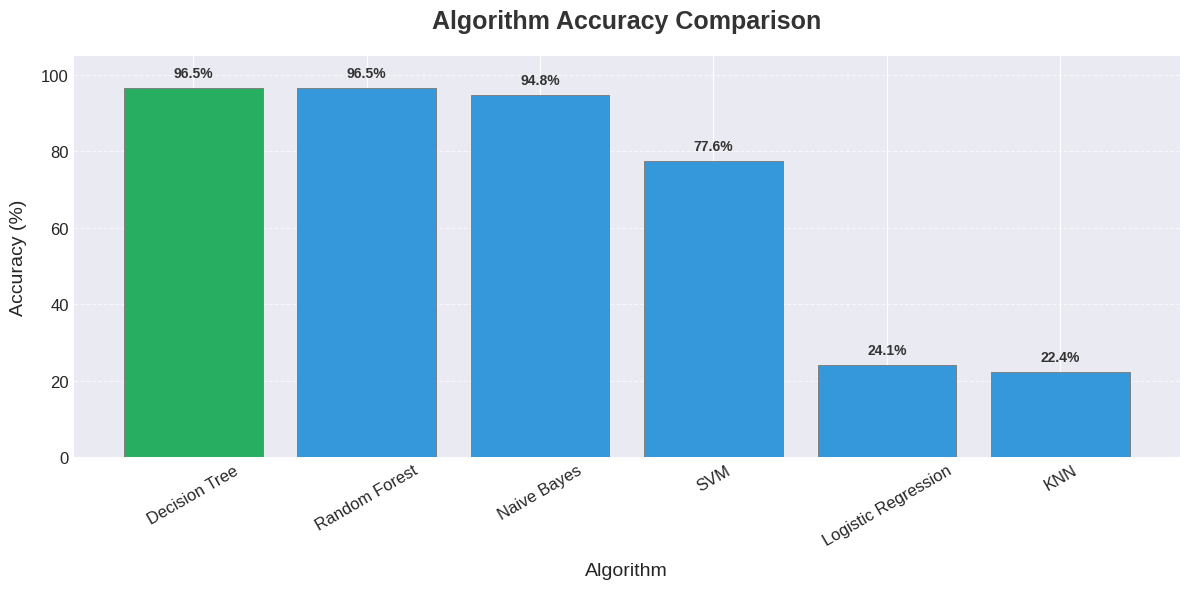

In [48]:
plt.style.use('seaborn-v0_8-darkgrid') # Apply a clean style

# -- Accuracy Comparison Bar Chart --
fig, ax = plt.subplots(figsize=(12, 6))

# Ensure the best algorithm gets a distinct color
colors = ['#27ae60' if name == best_algo else '#3498db' for name in results_df['Algorithm']]

bars = ax.bar(results_df['Algorithm'], results_df['Accuracy'],
              color=colors, edgecolor='gray', linewidth=0.7)

ax.set_title('Algorithm Accuracy Comparison', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_ylabel('Accuracy (%)', fontsize=14, labelpad=10)
ax.set_xlabel('Algorithm', fontsize=14, labelpad=10)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 20)) # Set major ticks at 20% intervals
ax.tick_params(axis='x', rotation=30, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Add grid lines for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2, # Increased vertical offset
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Customize spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')

plt.tight_layout()
plt.savefig('output_graphs/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
plt.style.use('default')

**MOVIE RECOMMENDATION FUNCTION**

In [40]:
def recommend_movies(emotion: str, top_n: int = 5) -> pd.DataFrame:
    """Recommend top N popular movies for a given emotion."""
    emotion  = emotion.strip().title()
    mask     = df['emotions'].str.contains(emotion, case=False, na=False)
    filtered = df[mask]
    if filtered.empty:
        print(f"No movies found for: '{emotion}'")
        return pd.DataFrame()
    return (filtered[['title', 'genre', 'rating', 'emotions']]
            .sort_values('rating', ascending=False)
            .drop_duplicates('title')
            .head(top_n)
            .reset_index(drop=True))

**DEMO RECOMMENDATIONS**

In [34]:
print("\n" + "=" * 65)
print("  DEMO: EMOTION-BASED MOVIE RECOMMENDATIONS")
print("=" * 65)

for emo in ['Happy', 'Sad', 'Love', 'Inspirational', 'Romantic', 'Fear']:
    print(f"\nTop movies for '{emo.upper()}':")
    print("-" * 50)
    for _, row in recommend_movies(emo, top_n=3).iterrows():
        print(f"  {row['title']}  |  Rating: {row['rating']}")



  DEMO: EMOTION-BASED MOVIE RECOMMENDATIONS

Top movies for 'HAPPY':
--------------------------------------------------
  Maro Monagadu  |  Rating: 8.6
  Mallesham  |  Rating: 8.5
  Rangasthalam  |  Rating: 8.4

Top movies for 'SAD':
--------------------------------------------------
  Pichhodu  |  Rating: 9.5
  Daana Veera Soora Karna  |  Rating: 8.8
  Praana  |  Rating: 8.5

Top movies for 'LOVE':
--------------------------------------------------
  Mahanati  |  Rating: 8.5
  Sardar Dharmanna  |  Rating: 8.4
  Manmadhudu  |  Rating: 8.3

Top movies for 'INSPIRATIONAL':
--------------------------------------------------
  Sankarabharanam  |  Rating: 8.7
  Maro Monagadu  |  Rating: 8.6
  Ugranarasimham  |  Rating: 8.6

Top movies for 'ROMANTIC':
--------------------------------------------------
  C/o Kancharapalem  |  Rating: 9.0
  Nuvvu Naaku Nachchav  |  Rating: 8.7
  Kuruthipunal  |  Rating: 8.5

Top movies for 'FEAR':
--------------------------------------------------
  Sankarabh

**CONCLUSION**

In [45]:
print("\n" + "=" * 60)
print("  CONCLUSION")
print("=" * 60)

# Get the row corresponding to the best algorithm from the DataFrame
best_algo_row = results_df[results_df['Algorithm'] == best_algo].iloc[0]

print(f"""
Best Algorithm : {best_algo_row['Algorithm']}
Accuracy       : {best_algo_row['Accuracy']}
Precision      : {best_algo_row['Precision']}
Recall         : {best_algo_row['Recall']}
F1-Score       : {best_algo_row['F1-Score']}
""")


  CONCLUSION

Best Algorithm : Decision Tree
Accuracy       : 96.55
Precision      : 2.26
Recall         : 3.39
F1-Score       : 2.54

